In [1]:
import os
print(os.getcwd())
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

/content


In [3]:
import seaborn as sns

iris_df = sns.load_dataset('iris')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris_df.isnull().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
species,False


In [5]:
iris_df.isnull().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
species,False


In [6]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


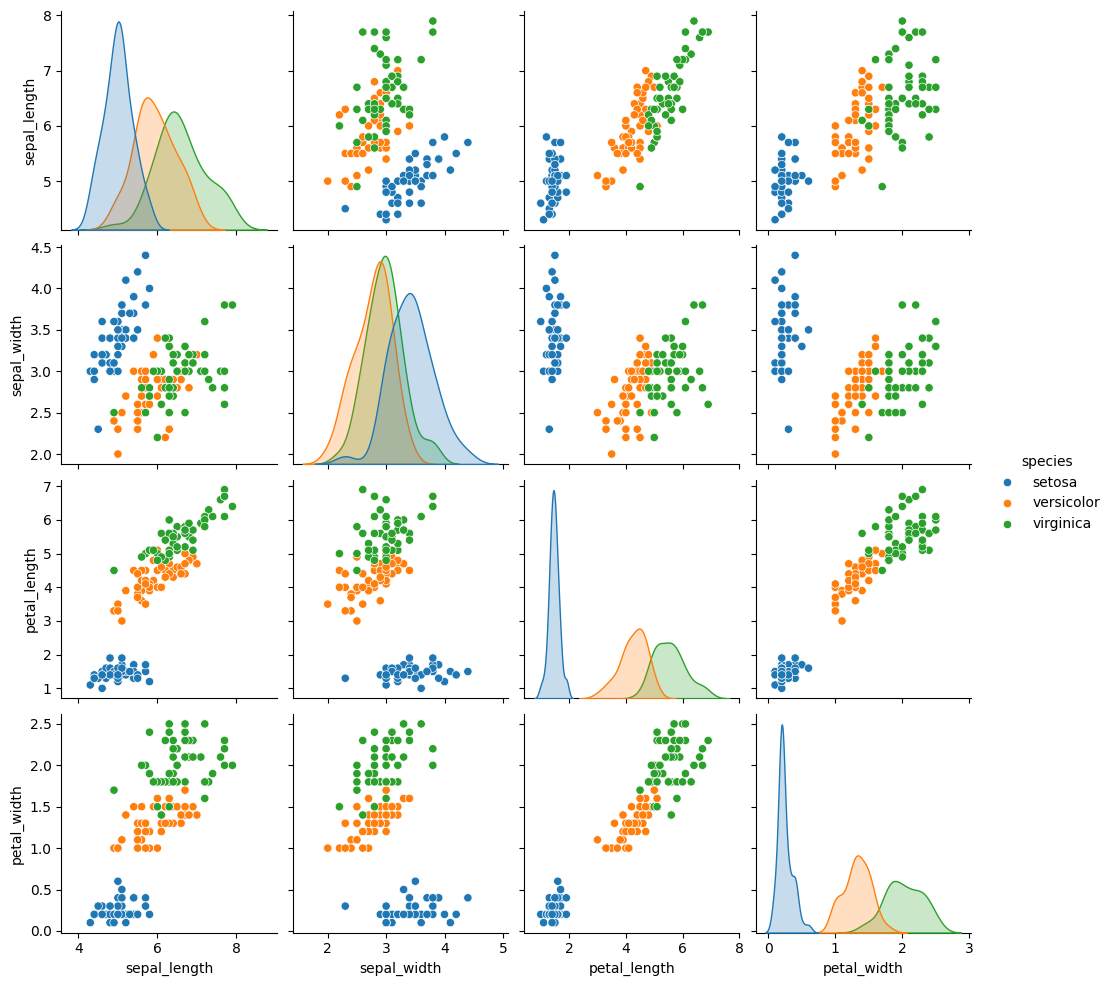

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
# Load the iris dataset
iris_df = sns.load_dataset('iris')
# Pair plot - using 'species' instead of 'Species'
sns.pairplot(iris_df, hue='species')
# Save the figure
plt.savefig("exercise2a.png")
# Display the figure
plt.show()

In [10]:
X = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris_df['species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9,random_state=1)




In [11]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)

In [15]:
print(classification_report(
y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



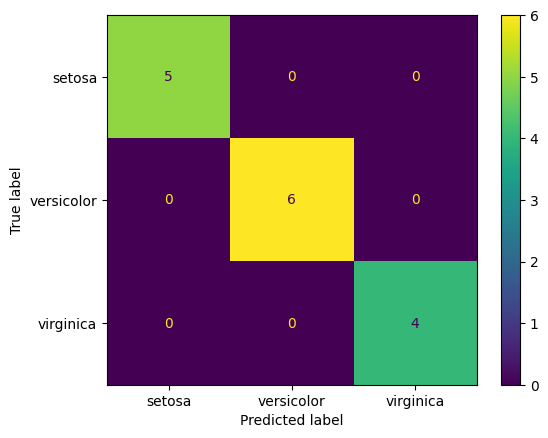

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Create and display confusion matrix directly from classifier
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.savefig("exercise2b.png")
plt.show()

In [17]:
!pip install pydotplus
!pip install graphviz

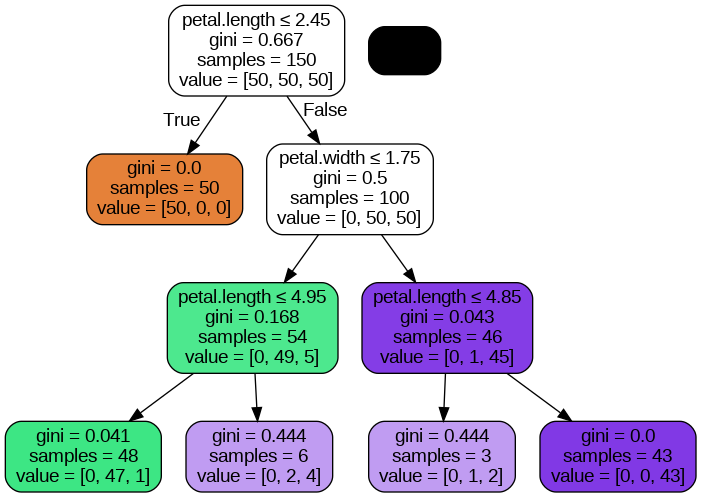

In [18]:
from io import StringIO
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import pydotplus
# from google.colab import files # Uncomment if using Google Colab
# 1. Load dataset and train the classifier
iris = load_iris()
X = iris.data
y = iris.target
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)
# 2. Export decision tree structure to Graphviz format
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
feature_names=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'],
filled=True, rounded=True, special_characters=True)
# 3. Create graph and handle visualization / saving
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# Save the file directly from the graph object
graph.write_png("exercise2c.png")
# Trigger download if in Colab environment
# files.download("exercise2c.png")
# Display inline
Image(graph.create_png())

In [19]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2
x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]
res = clf.predict(x)
# Simple class name mapping - only prints the predicted class
class_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
predicted_class = class_mapping[res[0]]
print("The class predicted is --> " + predicted_class)

The class predicted is --> setosa
